In [7]:
# Cell — full pipeline run using POPPY PSF

from dataclasses import replace
import numpy as np

from sim.camera import Camera
from sim.lens import Lens
from sim.frame import make_blank_frame, display_frame
from sim.mask import Mask
from sim.render import RenderConfig, render, plot_render_stages
from sim.physics.stars import load_star_field  # only if you want the on-sensor count
from sim.frame import plot_star_rois
from sim.frame import save_frame_fits

In [26]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.vizier import Vizier

def brightest_stars_near(ra_deg, dec_deg, radius_deg=8.0, n=20):
    """
    Query Gaia DR3 via VizieR around (ra,dec) and return the brightest (by G mag).
    """
    c = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs")
    v = Vizier(columns=["RA_ICRS", "DE_ICRS", "Gmag", "BPmag", "RPmag"], row_limit=5000)
    # Gaia DR3 main catalog in VizieR:
    cat = "I/355/gaiadr3"
    tab = v.query_region(c, radius=radius_deg*u.deg, catalog=cat)[0]
    tab.sort("Gmag")
    return tab[:n]

tab = brightest_stars_near(RA0_DEG, DEC0_DEG, radius_deg=10.0, n=15)
tab

RA_ICRS,DE_ICRS,Gmag,BPmag,RPmag
deg,deg,mag,mag,mag
float64,float64,float64,float64,float64
42.00429357726,61.50214242396,9.288476,9.643364,8.764083
42.19184029029,61.38011179533,9.330340,10.380602,8.329269
42.04191466685,61.49264550580,10.476943,11.155140,9.679454
36.02358033402,60.32250503371,11.130948,11.757315,10.349773
41.90424373526,61.30634143072,11.501384,11.702953,11.153445
41.81510600511,61.38074441352,11.557215,13.372136,10.286912
41.97886062619,61.40153496581,11.756378,12.647735,10.826951
36.08243610103,60.38299678966,11.779876,13.116586,10.654856


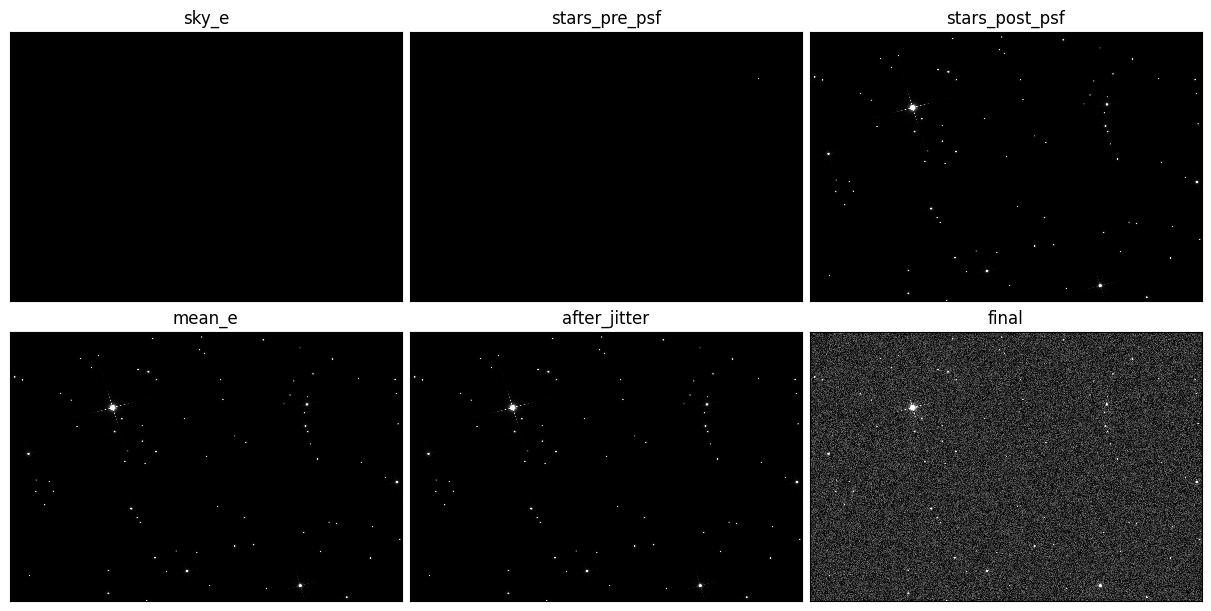

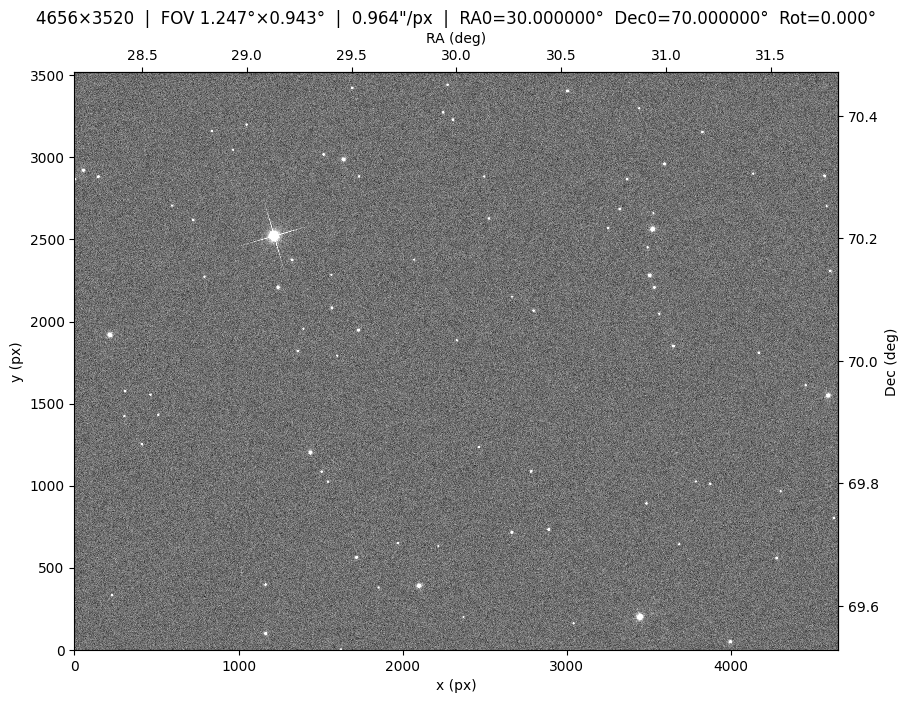

In [29]:
STAR_CSV = "sim/physics/starfields/field2.csv"

# Pointing
RA0_DEG  = 30
DEC0_DEG = 70
ROT_DEG  = 0.0

# Camera (your “astrocam” case)
cam = Camera(
    nx=4656,
    ny=3520,
    pixel_um=3.8,      # ASI1600 is 3.8 um
    read_noise_e=2.0,  # depends on gain; pick a realistic-ish value
    gain_e_per_adu=1.0,
    qe=0.6,
)

# 8" f/4 newtonian
lens = Lens(
    focal_mm=812.8,    # 203.2mm * 4
    f_number=4.0,
    transmission=0.9,
)

frame = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)

mask = Mask(
    kind="poppy",
    aperture_diam_mm=203.2,   # 8"
    obstruction_frac=0.30,    # tune 0.2–0.4
    vane_width_mm=0.76,       # 0.03"
    n_vanes=4,
    angle_deg=16.0,
    psf_size_px=513,          # 513/1025 is fine; cost grows fast
)

cfg = RenderConfig(
    exposure_s=90.0,
    sky_mu_mag_per_arcsec2=21.0,
    zeropoint_e_per_s=0.0,
    lambda_eff_nm=550.0,
    band_nm=90.0,

    # IMPORTANT:
    # this sigma now acts like seeing/focus blur on top of diffraction
    psf_sigma_px=1.2,          # try 0.4–1.2

    mask=mask,

    enable_sky=True,
    enable_stars=True,
    enable_psf=True,
    enable_jitter=False,
    enable_noise=True,

    seed=42,
)

frame2, res2 = render(frame, cfg, stars=STAR_CSV)

plot_render_stages(frame2, res2, cmap="gray", stretch="asinh", shared_scale=True)

# A nice final view
display_frame(frame2, cmap="gray", stretch="asinh", q_lo=0, q_hi=99.9)

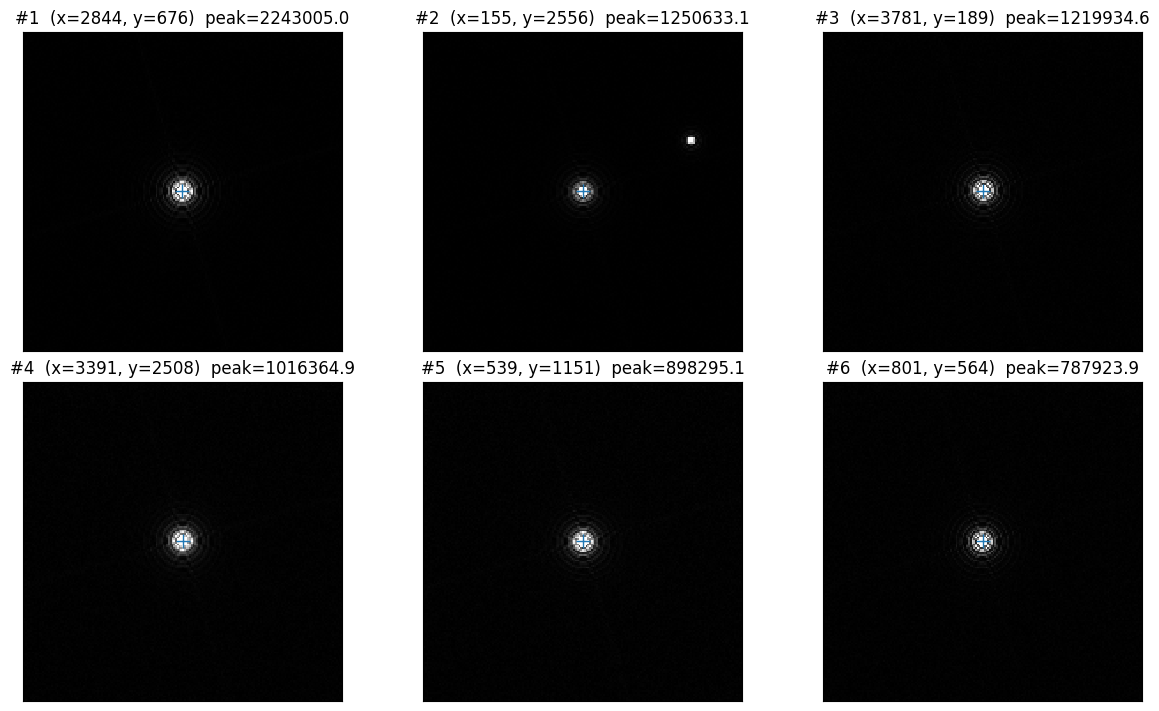

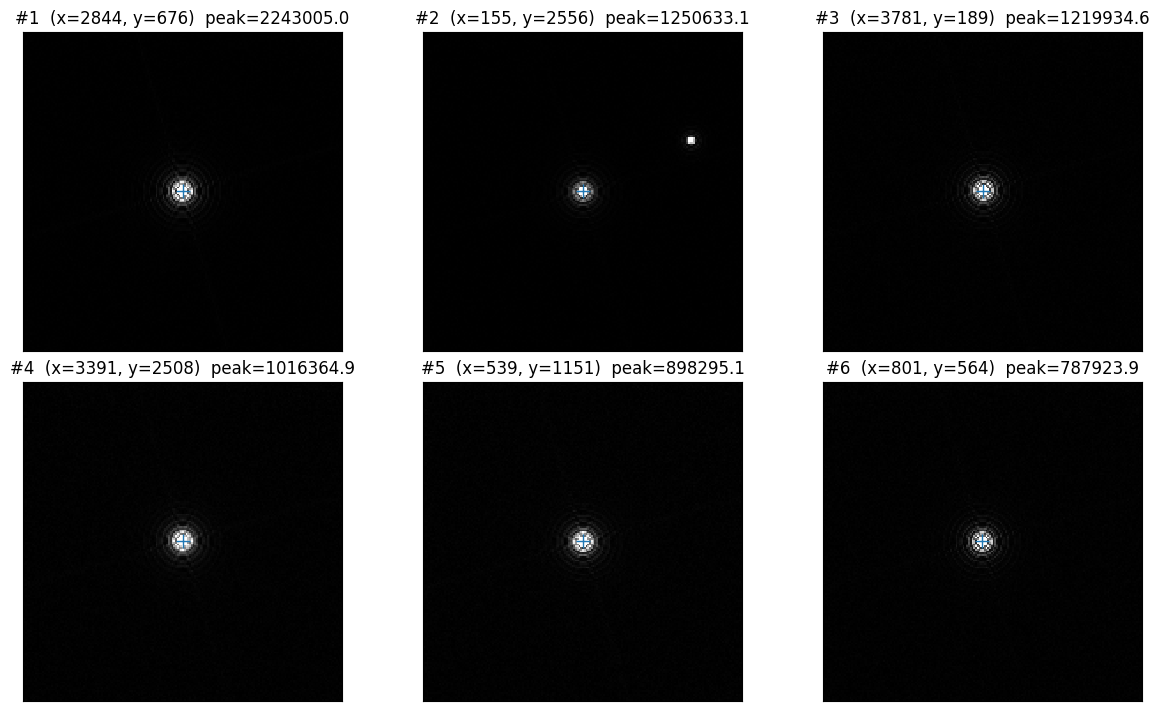

In [17]:
plot_star_rois(frame, image=res2.final_e,
               n=6, half_size=90, min_sep_px=180,
               stretch="log", cmap="gray")

In [25]:
out = save_frame_fits(
    "out/newt_asi1600_final_e4.fits",
    frame,
    cfg=cfg,
    res=res2,
    stage="final_e",
    stars_csv=STAR_CSV,
    overwrite=True,
)
print("Wrote:", out)

Wrote: out\newt_asi1600_final_e4.fits


In [11]:
img = res2.final_e
y0, x0 = np.unravel_index(np.argmax(img), img.shape)

# sample along +x direction from the star (one spike direction if aligned)
r = np.arange(10, 200)
vals = img[y0, x0 + r]

# local background stats from nearby patch
patch = img[max(0,y0-150):y0-50, max(0,x0-150):x0-50]
bkg_med = float(np.median(patch))
bkg_std = float(np.std(patch))

print("peak:", float(img[y0,x0]))
print("bkg median/std:", bkg_med, bkg_std)
print("spike @50px (above bkg, in sigma):", float((img[y0, x0+50]-bkg_med)/bkg_std))
print("spike @100px (above bkg, in sigma):", float((img[y0, x0+100]-bkg_med)/bkg_std))

peak: 423931.15625
bkg median/std: 90.12397766113281 9.69943904876709
spike @50px (above bkg, in sigma): 1.8428011958784336
spike @100px (above bkg, in sigma): 0.6101658319239605


In [18]:

img = res2.final_e
y0, x0 = np.unravel_index(np.argmax(img), img.shape)

patch = img[max(0,y0-150):y0-50, max(0,x0-150):x0-50]
bkg_med = float(np.median(patch))
bkg_std = float(np.std(patch))

print("peak:", float(img[y0, x0]))
print("bkg median/std:", bkg_med, bkg_std)
print("spike @50px (above bkg, in sigma):", float((img[y0, x0+50] - bkg_med)/bkg_std))
print("spike @100px (above bkg, in sigma):", float((img[y0, x0+100] - bkg_med)/bkg_std))

peak: 2243005.0
bkg median/std: 270.529296875 16.40603256225586
spike @50px (above bkg, in sigma): 1.0448073739816586
spike @100px (above bkg, in sigma): 0.3415912087748559


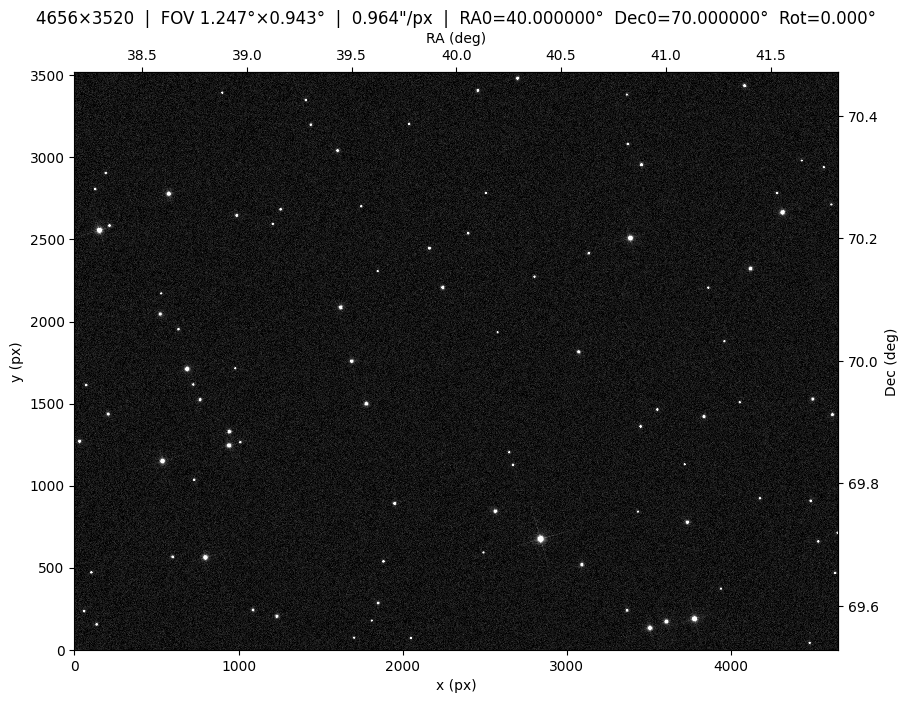

In [20]:
# Stack N frames to see spikes emerge naturally
N = 5
stack = np.zeros_like(res2.final_e, dtype=np.float64)

for i in range(N):
    cfg_i = replace(cfg, seed=42+i)  # different noise each time
    _, r = render(frame, cfg_i, stars=STAR_CSV)
    stack += r.final_e

stack = (stack / N).astype(np.float32)

frame_stack = frame  # reuse metadata
frame_stack.image = stack

display_frame(frame_stack, stretch="asinh", q_lo=5, q_hi=99.9)

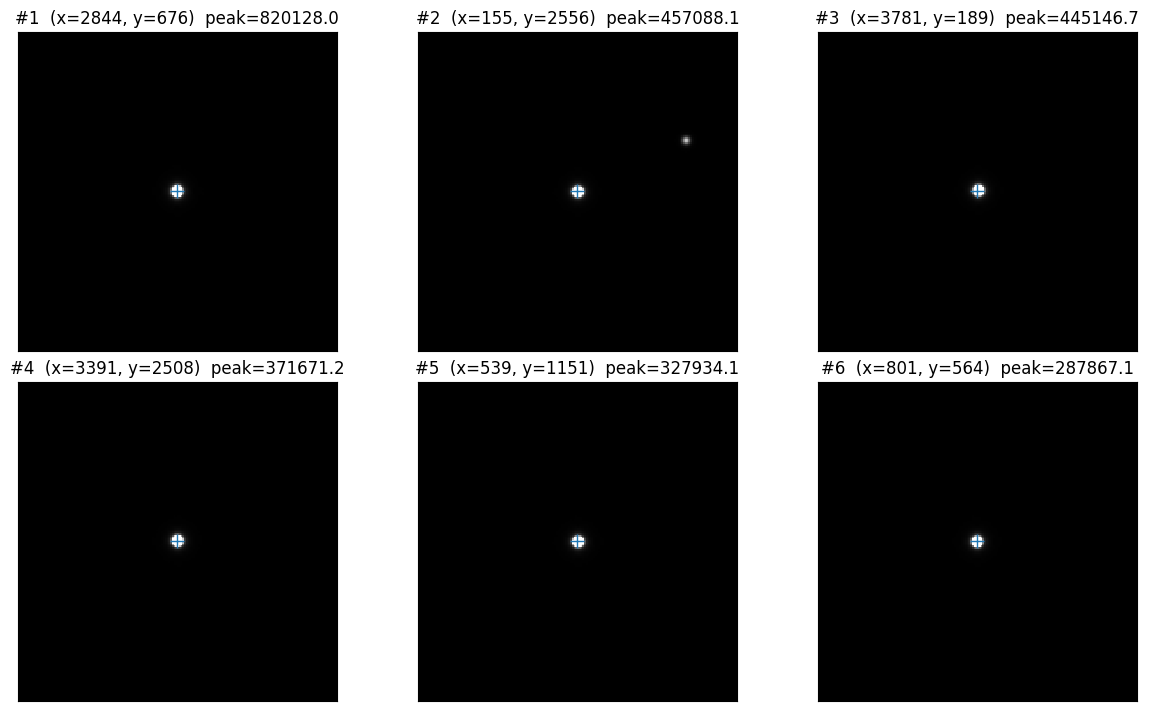

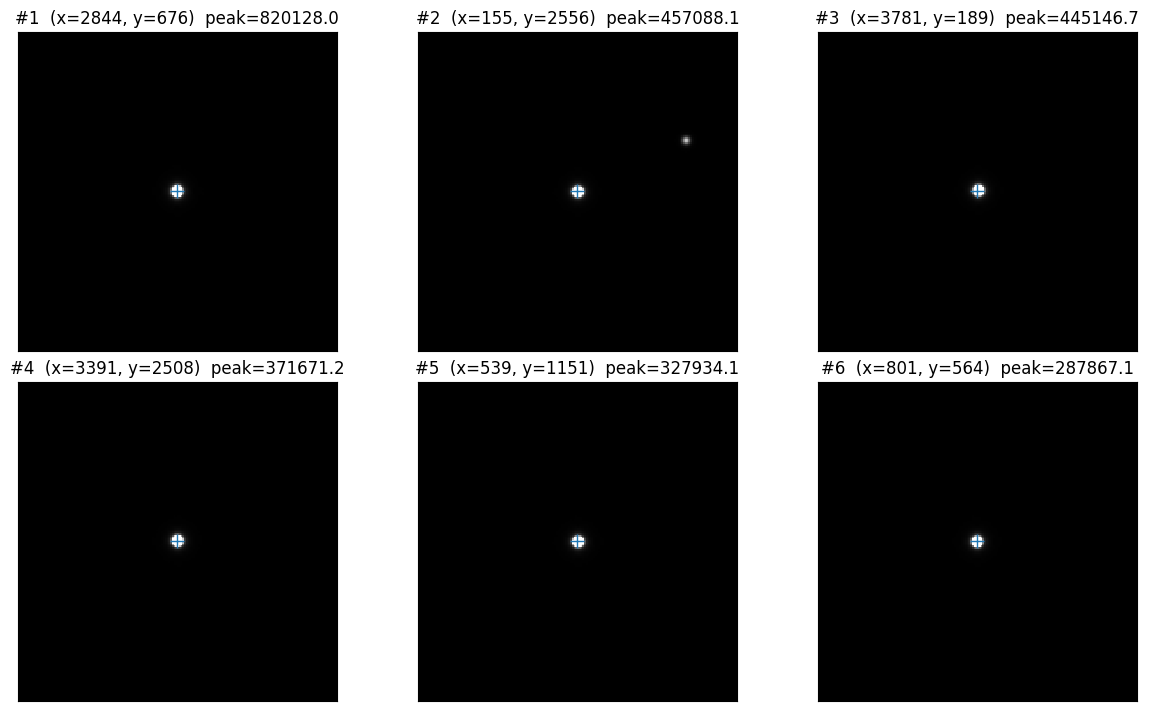

In [22]:
plot_star_rois(frame_stack, image=stack,
               n=6, half_size=90, min_sep_px=180,
               stretch="linear", cmap="gray")